# Prepare the PDFs

Extract the first page (the title page) for training a model.

Mostly working, works on all text based modern pdfs (but we shouldn't be  
scraping those anyway) but the image based scanned pdfs are still slightly  
touchy. The best area for improvement is in the OCR features of the image  
extraction script.

In [1]:
import os
import fitz  # PyMuPDF library

# Change this folder to run the script locally
pdf_folder = r'C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans'

# Define the name of the subfolder for the cover pages
output_folder = os.path.join(pdf_folder, 'cover pages')

# Create the output folder if it doesn't already exist
os.makedirs(output_folder, exist_ok=True)
print(f"Output folder created at: {output_folder}")

# Loop through all files in the specified PDF folder
for filename in os.listdir(pdf_folder):
    # Check if the file is a PDF
    if filename.lower().endswith('.pdf'):
        pdf_path = os.path.join(pdf_folder, filename)

        try:
            # Open the PDF file
            doc = fitz.open(pdf_path)

            # Get the first page (page index is 0)
            first_page = doc[0]

            # Render the page to an image (pixmap)
            pix = first_page.get_pixmap()

            # Create a name for the output image file (e.g., "my_document.png")
            base_filename = os.path.splitext(filename)[0]
            image_filename = f"{base_filename}.png"
            image_path = os.path.join(output_folder, image_filename)

            # Save the image
            pix.save(image_path)

            print(f"✅ Saved cover for: {filename}")

            # Close the document
            doc.close()

        except Exception as e:
            print(f"❌ Failed to process {filename}: {e}")

print("\n🎉 All done!")

Output folder created at: C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\cover pages
✅ Saved cover for: D02-13725-WOO-00795-5.89-1999-00.pdf
✅ Saved cover for: D02-8861-WOO-00018-13.57-2002-00.pdf
✅ Saved cover for: D02-9159-LUC-00002-31.75-1998-00.pdf
✅ Saved cover for: D02-9443-SAN-00053-11.78-2004-00.pdf
✅ Saved cover for: D03-11365-RIC-00071-8.08-1999-00.pdf
✅ Saved cover for: D03-11366-ASD-00071-9.13-1999-00.pdf
✅ Saved cover for: D03-11376-ERI-00002-10.88-1999-00.pdf
✅ Saved cover for: D03-11377-ERI-00002-7.11-1998-00.pdf
✅ Saved cover for: D03-11378-RIC-00071-19.08-2000-00.pdf
✅ Saved cover for: D03-11385-LOR-00090-13.2-2001-00.pdf
✅ Saved cover for: D03-13136-ERI-00250-11.34-2006-00.pdf
✅ Saved cover for: D03-13361-MED-00162-13.67-2002-00.pdf
✅ Saved cover for: D03-14016-WAY-00071-0.28-2001-00.pdf
✅ Saved cover for: D03-14017-WAY-00071-4.38-2004-00.pdf
✅ Saved cover for: D03-14018-MED-00071-13.3-2005-00.pdf
✅ Saved cover for: D03-7885-MED-00071-21.09-2000-0

# Annotate the Data

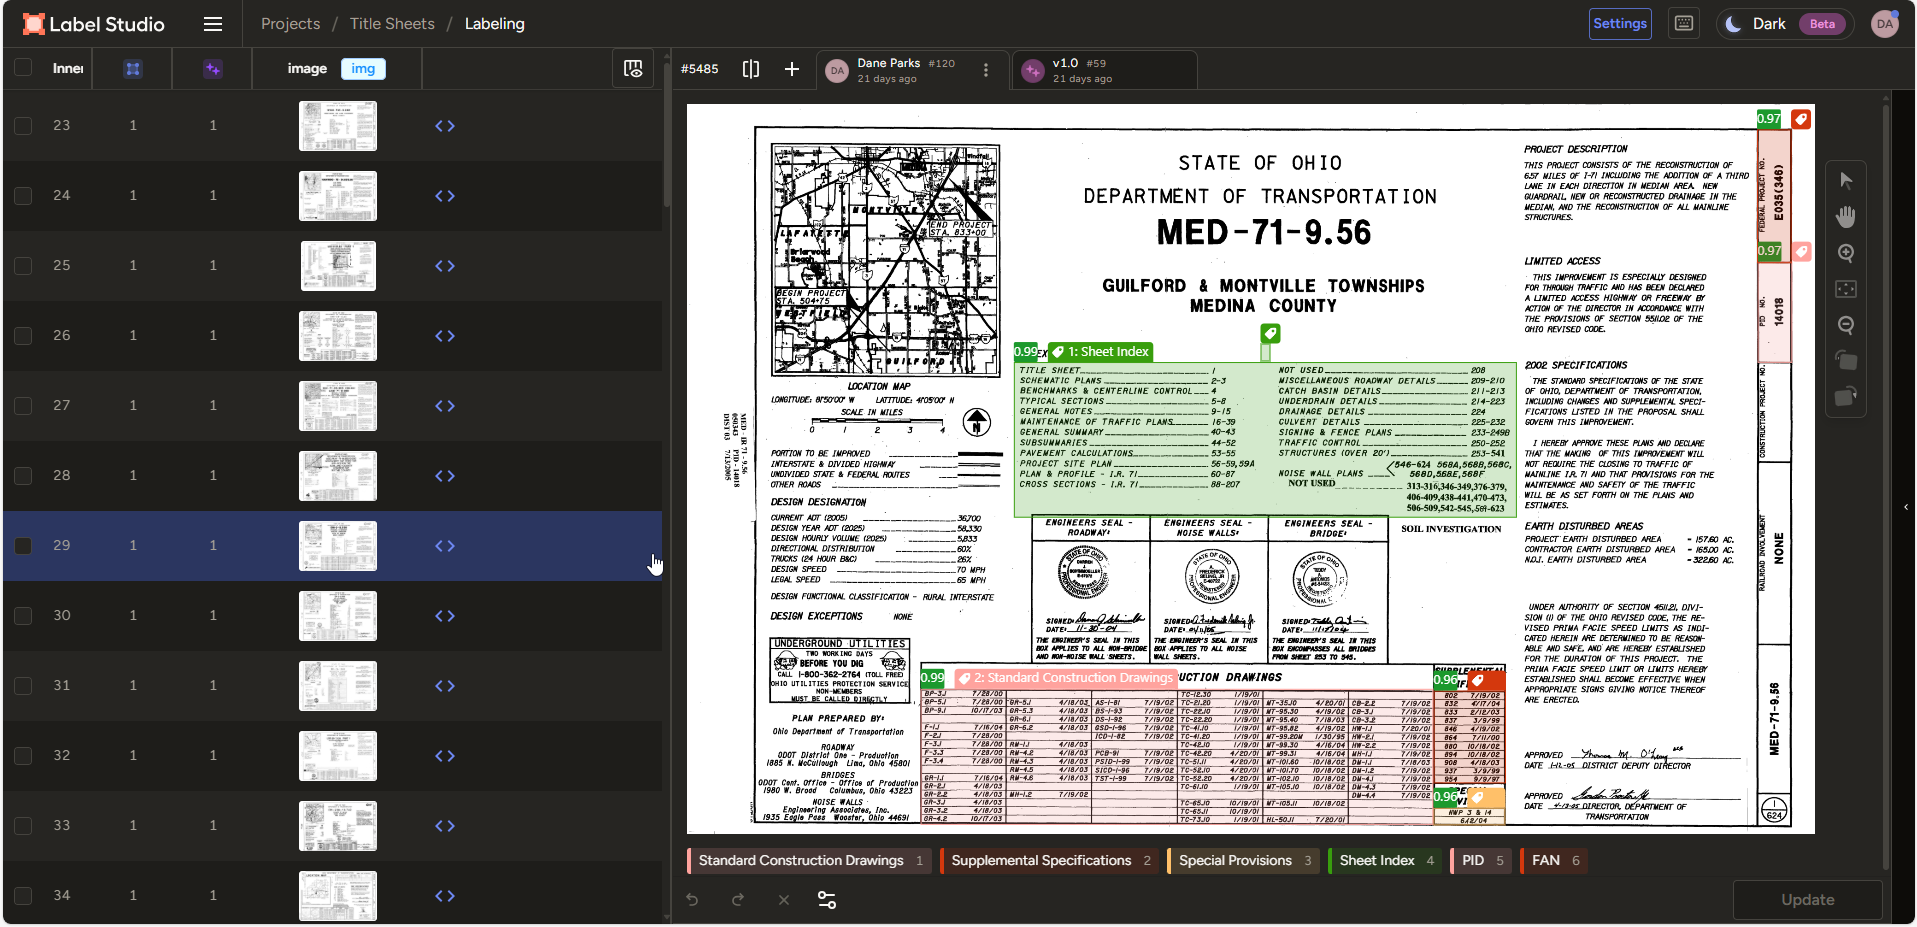

# Train the Model

In [ ]:
import os
import json
import torch
from PIL import Image
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
import torchvision.transforms as T
from urllib.parse import urlparse, parse_qs, unquote, quote

# --- Configuration ---
# ❗️ 1. Update this to the full path of your exported JSON file
LABEL_STUDIO_EXPORT_PATH = r"C:\Users\dparks1\Downloads\title_sheet_labels.json"

# --- End Configuration ---

# --- Global Settings ---
SOURCE_IMAGE_FOLDER = r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\DownloadedPlans\cover pages"
MODEL_OUTPUT_PATH = "trained_model.pth"
PREDICTIONS_OUTPUT_PATH = "predictions.json"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


# --- Step 1: Parse Label Studio JSON (for training data) ---
def setup_training_data():
    """
    Parses the Label Studio export to get ONLY the labeled data for training.
    """
    print("--- Step 1: Setting up training data ---")

    with open(LABEL_STUDIO_EXPORT_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)

    image_annotations_list = []
    all_labels = set()

    for task in tqdm(data, desc="Finding labeled images for training"):
        try:
            if not task.get('annotations') or not task['annotations'][0].get('result'):
                continue

            image_url = task['data']['image']
            parsed_url = urlparse(image_url)
            query_params = parse_qs(parsed_url.query)

            if 'd' not in query_params:
                continue

            decoded_path = unquote(query_params['d'][0])
            image_name = os.path.basename(decoded_path)

            if not image_name:
                continue

            local_image_path = os.path.join(SOURCE_IMAGE_FOLDER, image_name)

            if not os.path.exists(local_image_path):
                print(f"Warning: Could not find training image '{image_name}'. Skipping.")
                continue

            annotations = []
            for res in task['annotations'][0]['result']:
                val = res.get('value', {})
                labels = val.get('rectanglelabels')
                if not labels:
                    continue

                label = labels[0]
                all_labels.add(label)
                box = [val['x'], val['y'], val['width'], val['height']]
                annotations.append({'box': box, 'label': label})

            if annotations:
                image_annotations_list.append({"image_path": local_image_path, "annotations": annotations})

        except (KeyError, IndexError) as e:
            print(f"Skipping a task due to a parsing error: {e}")
            continue

    print(f"Successfully processed {len(image_annotations_list)} tasks for training.")
    print(f"Discovered labels: {all_labels}")
    return image_annotations_list, sorted(list(all_labels))


# --- Step 2: Create a Custom PyTorch Dataset ---
class ObjectDetectionDataset(Dataset):
    def __init__(self, image_annotations, label_map, transforms):
        self.image_annotations = image_annotations
        self.label_map = label_map
        self.transforms = transforms

    def __len__(self):
        return len(self.image_annotations)

    def __getitem__(self, idx):
        item = self.image_annotations[idx]
        image = Image.open(item['image_path']).convert("RGB")
        width, height = image.size

        boxes = []
        labels = []
        for ann in item['annotations']:
            box_ls = ann['box']
            xmin = box_ls[0] * width / 100
            ymin = box_ls[1] * height / 100
            xmax = (box_ls[0] + box_ls[2]) * width / 100
            ymax = (box_ls[1] + box_ls[3]) * height / 100
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.label_map[ann['label']])

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64)
        }

        if self.transforms:
            image = self.transforms(image)

        return image, target


def get_transform():
    return T.ToTensor()


def collate_fn(batch):
    return tuple(zip(*batch))


# --- Step 3: Train the Model ---
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def train_model(image_annotations, label_names):
    print("\n--- Step 2: Training model ---")
    label_map = {name: i + 1 for i, name in enumerate(label_names)}
    num_classes = len(label_names) + 1

    dataset = ObjectDetectionDataset(image_annotations, label_map, get_transform())
    train_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

    model = get_model(num_classes)
    model.to(DEVICE)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    num_epochs = 20

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            train_loss += losses.item()

        print(f"Epoch {epoch + 1} Train Loss: {train_loss / len(train_loader):.4f}")

    torch.save(model.state_dict(), MODEL_OUTPUT_PATH)
    print(f"Model saved to '{MODEL_OUTPUT_PATH}'")


# --- Step 4: Generate Predictions for ALL Images in the Source Folder ---
def generate_predictions_for_all_images(label_names):
    """
    Scans the source image folder and generates predictions for every image.
    """
    print("\n--- Step 3: Generating predictions for all images in the folder ---")
    if not os.path.exists(MODEL_OUTPUT_PATH):
        print("Model file not found. Please train the model first.")
        return

    id2label = {i + 1: name for i, name in enumerate(label_names)}
    num_classes = len(label_names) + 1

    model = get_model(num_classes)
    model.load_state_dict(torch.load(MODEL_OUTPUT_PATH))
    model.to(DEVICE)
    model.eval()

    predictions = []
    transform = get_transform()

    image_files = [f for f in os.listdir(SOURCE_IMAGE_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for image_name in tqdm(image_files, desc="Generating predictions"):
        local_image_path = os.path.join(SOURCE_IMAGE_FOLDER, image_name)

        try:
            image = Image.open(local_image_path).convert("RGB")
            width, height = image.size

            img_tensor = transform(image)

            with torch.no_grad():
                prediction = model([img_tensor.to(DEVICE)])[0]

            ls_results = []
            for score, label_id, box in zip(prediction["scores"], prediction["labels"], prediction["boxes"]):
                if score < 0.7:
                    continue

                if label_id.item() not in id2label:
                    continue

                label_name = id2label[label_id.item()]
                xmin, ymin, xmax, ymax = box.tolist()

                ls_value = {
                    "x": (xmin / width) * 100, "y": (ymin / height) * 100,
                    "width": ((xmax - xmin) / width) * 100, "height": ((ymax - ymin) / height) * 100,
                    "rotation": 0, "rectanglelabels": [label_name]
                }

                ls_results.append({
                    "from_name": "label", "to_name": "image", "type": "rectanglelabels",
                    "score": score.item(), "value": ls_value
                })

            # Create the Label Studio 'data' object for this image
            # This formatting is crucial for Label Studio to find the local file
            encoded_path = quote(
                os.path.join("Users", os.getlogin(), "OneDrive - State of Ohio", "Documents", "DownloadedPlans",
                             "cover pages", image_name))
            image_url_for_ls = f"/data/local-files/?d={encoded_path}"

            predictions.append({
                "data": {"image": image_url_for_ls},
                "predictions": [{"model_version": "v1.0", "result": ls_results}]
            })
        except Exception as e:
            print(f"Failed to process {image_name}: {e}")

    with open(PREDICTIONS_OUTPUT_PATH, 'w') as f:
        json.dump(predictions, f, indent=2)

    print(f"\n✅ Predictions for {len(image_files)} images saved to '{PREDICTIONS_OUTPUT_PATH}'")


# --- Main Execution ---
if __name__ == '__main__':
    training_data, discovered_labels = setup_training_data()

    if training_data and discovered_labels:
        train_model(training_data, discovered_labels)
        generate_predictions_for_all_images(discovered_labels)
    else:
        print("Setup failed. No training data found in JSON.")


Using device: cuda
--- Step 1: Setting up training data ---


Finding labeled images for training: 100%|██████████| 139/139 [00:00<00:00, 9719.72it/s]

Successfully processed 139 tasks for training.
Discovered labels: {'Sheet Index', 'PID', 'Special Provisions', 'Supplemental Specifications', 'FAN', 'Standard Construction Drawings'}

--- Step 2: Training model ---



Epoch 1/20: 100%|██████████| 70/70 [00:44<00:00,  1.58it/s]


Epoch 1 Train Loss: 0.8775


...

Epoch 15/20: 100%|██████████| 70/70 [00:36<00:00,  1.91it/s]


Epoch 15 Train Loss: 0.1405


Epoch 16/20: 100%|██████████| 70/70 [00:37<00:00,  1.88it/s]


Epoch 16 Train Loss: 0.1482


Epoch 17/20:  24%|██▍       | 17/70 [00:08<00:27,  1.94it/s]

# Testing the Model

In [ ]:
path_to_text_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\ODOT Sample Plans.pdf"
path_to_image_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"

In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
import matplotlib.pyplot as plt
import fitz  # PyMuPDF
import torchvision.transforms as T
import os
import camelot
import pandas as pd

# You will need to install pytesseract and Google's Tesseract-OCR engine
# pip install pytesseract
# Installation instructions for Tesseract: https://github.com/tesseract-ocr/tesseract
import pytesseract


# --- Global Configuration & Model Loading ---

# This list MUST match the labels discovered during training.
DISCOVERED_LABELS = sorted([
    'PID', 'Supplemental Specifications', 'Sheet Index', 'FAN',
    'Standard Construction Drawings', 'Special Provisions'
])

# Use GPU if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def get_model(num_classes):
    """
    Defines the Faster R-CNN model architecture.
    This must be identical to the function in your training script.
    """
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
def load_trained_model(model_path):
    """
    Loads the trained model weights and prepares it for inference.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")
        
    print(f"Using device: {DEVICE}")
    num_classes = len(DISCOVERED_LABELS) + 1  # +1 for the background class
    
    model = get_model(num_classes)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()  # Set the model to evaluation mode
    print("Model loaded successfully!")
    return model

In [ ]:
# --- Step 1: Finder Functions ---

def find_section_in_pdf(model, pdf_path, target_label, page_number=1):
    """
    Finds a labeled section in a PDF and returns its coordinates and related info.
    This function performs inference but does not display output.
    """
    if not os.path.exists(pdf_path):
        print(f"Error: PDF not found at {pdf_path}")
        return None
    
    doc = fitz.open(pdf_path)
    page_index = page_number - 1
    if not (0 <= page_index < len(doc)):
        print(f"Error: Page {page_number} is invalid. PDF has {len(doc)} pages.")
        doc.close()
        return None
    
    page = doc[page_index]
    pix = page.get_pixmap(dpi=200)
    # Store the original PDF page dimensions for coordinate conversion
    page_dimensions = (page.rect.width, page.rect.height)
    doc.close()
    
    original_image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    
    # Use the generalized image finder for the core model inference
    info = find_section_in_image(model, original_image, target_label)
    if info:
        info["page_dimensions"] = page_dimensions
        info["page_number"] = page_number
    return info

In [ ]:
def find_section_in_image(model, image_obj_or_path, target_label):
    """
    Finds a labeled section in an image and returns a dictionary of information.
    """
    if isinstance(image_obj_or_path, str):
        if not os.path.exists(image_obj_or_path):
            print(f"Error: Image file not found at {image_obj_or_path}")
            return None
        original_image = Image.open(image_obj_or_path).convert("RGB")
    else: # Assumes it's a PIL Image object
        original_image = image_obj_or_path

    id2label = {i + 1: name for i, name in enumerate(DISCOVERED_LABELS)}
    
    transform = T.ToTensor()
    img_tensor = transform(original_image).to(DEVICE)
    
    with torch.no_grad():
        prediction = model([img_tensor])[0]

    best_box, best_score = None, 0.0
    for score, label_id, box in zip(prediction["scores"], prediction["labels"], prediction["boxes"]):
        if label_id.item() in id2label and id2label[label_id.item()] == target_label:
            if score > best_score:
                best_score, best_box = score, box.cpu().numpy()
    
    if best_box is not None:
        print(f"Found '{target_label}' with confidence {best_score:.4f}")
        return {
            "best_box": best_box,
            "best_score": best_score,
            "original_image": original_image
        }
    else:
        print(f"Could not find a bounding box for '{target_label}'.")
        return None

In [ ]:
# --- Step 2: Data Extraction Functions ---

def extract_table_or_text(pdf_path, bounding_box_info):
    """
    Uses a bounding box to extract a table with Camelot. If it fails,
    it falls back to extracting text with OCR.
    """
    if not bounding_box_info or bounding_box_info.get("best_box") is None:
        print("Error: Invalid bounding_box_info provided.")
        return None

    # Unpack the info dictionary
    best_box = bounding_box_info["best_box"]
    original_image = bounding_box_info["original_image"]
    page_dims = bounding_box_info["page_dimensions"]
    page_num = bounding_box_info["page_number"]

    xmin_pix, ymin_pix, xmax_pix, ymax_pix = best_box
    img_width, img_height = original_image.size
    pdf_page_width, pdf_page_height = page_dims

    # --- Expand the bounding box before conversion ---
    # This gives Camelot a larger area to search in, capturing headers/footers.
    # We are increasing these values significantly to ensure the full table is included.
    y_expansion_up = 150      # Increased upward expansion to catch top rows/headers.
    y_expansion_down = 400    # Increased downward expansion to capture the rest of the table.
    x_expansion = 50          # Increased horizontal expansion to avoid cutting off columns.

    ymin_pix = max(0, ymin_pix - y_expansion_up)
    ymax_pix = min(img_height, ymax_pix + y_expansion_down)
    xmin_pix = max(0, xmin_pix - x_expansion)
    xmax_pix = min(img_width, xmax_pix + x_expansion)
    # --- End Expansion ---

    # --- Coordinate Conversion for Camelot ---
    # Camelot's coordinate system has (0,0) at the BOTTOM-LEFT corner of the page.
    pdf_x1 = xmin_pix * (pdf_page_width / img_width)
    pdf_x2 = xmax_pix * (pdf_page_width / img_width)
    # The model gives y-coordinates from the top-left, so we must flip them for Camelot.
    pdf_y1_from_top = ymin_pix * (pdf_page_height / img_height)
    pdf_y2_from_top = ymax_pix * (pdf_page_height / img_height)
    
    camelot_y1 = pdf_page_height - pdf_y1_from_top # This becomes the TOP y-coordinate in Camelot
    camelot_y2 = pdf_page_height - pdf_y2_from_top # This becomes the BOTTOM y-coordinate in Camelot

    # The table_area string requires x1, y_top, x2, y_bottom
    table_area_str = f"{pdf_x1},{camelot_y1},{pdf_x2},{camelot_y2}"
    print(f"\nAttempting table extraction in area: {table_area_str} on page {page_num}")

    try:
        tables = camelot.read_pdf(
            pdf_path,
            pages=str(page_num),
            flavor='stream',
            table_areas=[table_area_str]
        )

        if tables.n > 0:
            print("✅ Camelot found a table. PDF is likely text-based in this region.")
            return {"type": "table", "data": tables[0].df}
        else:
            print("ℹ️ Camelot did not find a table. This section might be an image. Attempting OCR...")
            # Crop the original image using pixel coordinates for OCR
            cropped_for_ocr = original_image.crop((xmin_pix, ymin_pix, xmax_pix, ymax_pix))
            ocr_text = _extract_text_with_ocr(cropped_for_ocr)
            
            if ocr_text:
                return {"type": "text", "data": ocr_text}
            else:
                return None
    except Exception as e:
        print(f"An error occurred during Camelot extraction: {e}")
        return None

In [ ]:
def _extract_text_with_ocr(cropped_image_obj):
    """Helper function to run Tesseract OCR on a cropped image."""
    try:
        extracted_text = pytesseract.image_to_string(cropped_image_obj)
        if extracted_text and extracted_text.strip():
            print("✅ OCR successfully extracted text from the image.")
            return extracted_text
        else:
            print("ℹ️ OCR ran, but found no text in the image region.")
            return None
    except pytesseract.TesseractNotFoundError:
        print("\n--- OCR ERROR: Tesseract is not installed or not in your PATH. ---")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during OCR: {e}")
        return None

In [ ]:
# --- Step 3: Display Function ---

def display_croppped_section(bounding_box_info, target_label):
    """
    Displays the original image and the cropped section based on bounding box info.
    """
    if not bounding_box_info or bounding_box_info.get("best_box") is None:
        print("Cannot display results: Invalid bounding_box_info provided.")
        return

    original_image = bounding_box_info["original_image"]
    best_box = bounding_box_info["best_box"]
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].imshow(original_image)
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    xmin, ymin, xmax, ymax = best_box
    
    # Expand the box slightly for better visual cropping
    expansion_pixels = 30
    img_width, img_height = original_image.size
    xmin = max(0, xmin - expansion_pixels)
    ymin = max(0, ymin - expansion_pixels)
    xmax = min(img_width, xmax + expansion_pixels)
    
    cropped_image = original_image.crop((xmin, ymin, xmax, ymax))
    axs[1].imshow(cropped_image)
    axs[1].set_title(f"Cropped: '{target_label}'")
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Running the Code on an "Image based" PDF File

In [ ]:
# ❗️ 1. Make sure this path points to your trained model file.
MODEL_PATH = "trained_model.pth"

# Load the model only once at the start
trained_model = load_trained_model(MODEL_PATH)

# ❗️ 2. Configure your extraction task
pdf_to_process = path_to_image_file
label_to_find = "Standard Construction Drawings"
page_to_process = 1

# --- Workflow ---

# STEP 1: Find the section in the PDF. This returns a dictionary of info.
print(f"\n--- STEP 1: Finding '{label_to_find}' on page {page_to_process} ---")
box_info = find_section_in_pdf(trained_model, pdf_to_process, label_to_find, page_number=page_to_process)

# STEP 2: If a section was found, attempt to extract data from it.
if box_info:
    print("\n--- STEP 2: Attempting data extraction from the found section ---")
    extraction_result = extract_table_or_text(pdf_to_process, box_info)
    
    if extraction_result:
        if extraction_result["type"] == "table":
            print("\n--- Extracted DataFrame ---")
            df = extraction_result["data"]
            print(df.head()) # Print first 5 rows
        elif extraction_result["type"] == "text":
            print("\n--- Extracted Text (from OCR) ---")
            text = extraction_result["data"]
            print(text[:500] + "...") # Print first 500 characters
    
    # STEP 3 (Optional): Display the visual crop of the area.
    print("\n--- STEP 3: Displaying the cropped area for verification ---")
    display_croppped_section(box_info, label_to_find)

## Running on a Text Based PDF File

In [ ]:
# This is the magic command
%matplotlib inline

# ❗️ 1. Make sure this path points to your trained model file.
MODEL_PATH = "trained_model.pth"

# Load the model only once at the start
trained_model = load_trained_model(MODEL_PATH)

# ❗️ 2. Configure your extraction task
pdf_to_process = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\ODOT Sample Plans.pdf"
label_to_find = "Standard Construction Drawings"
page_to_process = 3

# --- Workflow ---

# STEP 1: Find the section in the PDF.
print(f"\n--- STEP 1: Finding '{label_to_find}' on page {page_to_process} ---")
box_info = find_section_in_pdf(trained_model, pdf_to_process, label_to_find, page_number=page_to_process)

if box_info:
    # STEP 2: Visualize the Camelot search area BEFORE extraction.
    print("\n--- STEP 2: Displaying the area Camelot will search ---")
    visualize_camelot_search_area(pdf_to_process, box_info)

    # STEP 3: Attempt to extract data from the found section.
    print("\n--- STEP 3: Attempting data extraction from the found section ---")
    extraction_result = extract_table_or_text(pdf_to_process, box_info)
    
    # STEP 4 (Optional): Display the visual crop of the area for final verification.
    print("\n--- STEP 4: Displaying the final cropped area ---")
    display_croppped_section(box_info, label_to_find)

In [ ]:
example_path = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"

In [ ]:
# This can now be a path to a PDF or an image file (e.g., .pdf, .png, .jpg, .tiff)
INPUT_FILE_PATH = example_path
TARGET_LABEL = "Standard Construction Drawings" # The section you want to extract

# --- EXECUTION ---
file_extension = os.path.splitext(INPUT_FILE_PATH)[1].lower()

if file_extension in ['.xlsx', '.xls']:
    # MODE 2: Convert an existing Excel file to JSON
    convert_excel_to_json(INPUT_FILE_PATH)

elif file_extension in ['.pdf', '.png', '.jpg', '.jpeg', '.tiff', '.tif']:
    # MODE 1: Full extraction from PDF or Image
    if not os.path.exists(MODEL_PATH) or not os.path.exists(INPUT_FILE_PATH):
        print("---" * 20 + "\n!!! SETUP REQUIRED (Extraction Mode) !!!")
        print(f"Please update MODEL_PATH and INPUT_FILE_PATH in the '__main__' block.")
        print(f"Current MODEL_PATH: {MODEL_PATH}")
        print(f"Current INPUT_FILE_PATH: {INPUT_FILE_PATH}\n" + "---" * 20)
    else:
        model = load_trained_model(MODEL_PATH)
        
        extracted_result = process_document(
            model, 
            file_path=INPUT_FILE_PATH, 
            target_label=TARGET_LABEL, 
            page_number=1 # Ignored for image files
        )
        
        if extracted_result:
            print("\n\n" + "---" * 15 + "\n      RAW EXTRACTED DATA\n" + "---" * 15)
            print(f"Extraction Type: {extracted_result['type']}")
            with pd.option_context('display.max_rows', 20, 'display.max_columns', None, 'display.width', 1000):
                print(extracted_result['data'])
            
            export_for_review(extracted_result)
else:
    print(f"Error: Unsupported file format in INPUT_FILE_PATH: {file_extension}")
    print("Please provide a path to a PDF, image, or Excel file.")

In [ ]:
# This can now be a path to a PDF or an image file (e.g., .pdf, .png, .jpg, .tiff)
INPUT_FILE_PATH = r"C:\Users\dparks1\AppData\Local\Temp\tmpkhk4n2_m.xlsx"
TARGET_LABEL = "Standard Construction Drawings" # The section you want to extract

# --- EXECUTION ---
file_extension = os.path.splitext(INPUT_FILE_PATH)[1].lower()

if file_extension in ['.xlsx', '.xls']:
    # MODE 2: Convert an existing Excel file to JSON
    convert_excel_to_json(INPUT_FILE_PATH)

elif file_extension in ['.pdf', '.png', '.jpg', '.jpeg', '.tiff', '.tif']:
    # MODE 1: Full extraction from PDF or Image
    if not os.path.exists(MODEL_PATH) or not os.path.exists(INPUT_FILE_PATH):
        print("---" * 20 + "\n!!! SETUP REQUIRED (Extraction Mode) !!!")
        print(f"Please update MODEL_PATH and INPUT_FILE_PATH in the '__main__' block.")
        print(f"Current MODEL_PATH: {MODEL_PATH}")
        print(f"Current INPUT_FILE_PATH: {INPUT_FILE_PATH}\n" + "---" * 20)
    else:
        model = load_trained_model(MODEL_PATH)
        
        extracted_result = process_document(
            model, 
            file_path=INPUT_FILE_PATH, 
            target_label=TARGET_LABEL, 
            page_number=1 # Ignored for image files
        )
        
        if extracted_result:
            print("\n\n" + "---" * 15 + "\n      RAW EXTRACTED DATA\n" + "---" * 15)
            print(f"Extraction Type: {extracted_result['type']}")
            with pd.option_context('display.max_rows', 20, 'display.max_columns', None, 'display.width', 1000):
                print(extracted_result['data'])
            
            export_for_review(extracted_result)
else:
    print(f"Error: Unsupported file format in INPUT_FILE_PATH: {file_extension}")
    print("Please provide a path to a PDF, image, or Excel file.")

Here is the final output of that json file,

```json
{
    "BP-3.1": "07-16-04",
    "MT-35.10": "04-20-01",
    "AS-1-81": "07-19-02",
    "BP-5.1": "07-28-00",
    "MT-95.30": "09-05-06",
    "BR-1": "07-19-02",
    "MT-99.20M": "01-30-95",
    "CPA-5-94": "07-19-02",
    "MT-101.70": "10-18-02",
    "CS-1-03": "04-18-03",
    "F-1.1": "07-16-04",
    "MT-102.20": "09-05-06",
    "EXJ-4-87": "07-19-02",
    "MT-105.10": "10-18-02",
    "GSD-1-96": "07-19-02",
    "MT-105.11": "10-18-02",
    "PCB-91": "07-19-02",
    "GR-1.1": "07-16-04",
    "GR-2.1": "01-16-04",
    "GR-3.4": "04-18-03",
    "TC-41.10": "01-19-01",
    "GR-3.2": "04-18-03",
    "TC-42.10": "01-19-01",
    "TC-42.20": "07-16-04",
    "TC-52.10": "04-20-01",
    "RM-4.2": "10-20-06",
    "TC-52.20": "04-20-01",
    "TC-65.11": "01-21-05",
    "TC-72.20": "01-21-05",
    "TC-73.10": "01-19-01"
}
```

# Packaged up Into a Deliverable

In [ ]:
from src.civilpy.state.ohio.DOT.title_sheet import process_document, export_for_review

In [ ]:
path_to_text_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\ODOT Sample Plans.pdf"
path_to_image_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"
MODEL_PATH = "trained_model.pth"
TARGET_LABEL = "Standard Construction Drawings" # The section you want to extract

In [ ]:
text_results = process_document(MODEL_PATH, path_to_text_file, TARGET_LABEL, page_number=3)

In [ ]:
results = process_document(MODEL_PATH, path_to_image_file, TARGET_LABEL)

In [ ]:
export_for_review(results)

In [ ]:
export_for_review(text_results)